In [ ]:
from google.colab import files

uploaded = files.upload()

Saving standardized_384.zip to standardized_384.zip


In [ ]:
import zipfile

zip_path = "/content/standardized_384.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Extraction complete!")

Extraction complete!


In [ ]:
import os

for item in os.listdir('/content'):
    print(item)

.config
standardized_384.zip
standardized_384
__MACOSX
sample_data


In [ ]:
import os

dataset_path = "/content/standardized_384"

print(os.listdir(dataset_path))

['paper', '.DS_Store', 'biological', 'clothes', 'metal', 'glass', 'cardboard', 'battery', 'plastic', 'shoes', 'trash']


In [ ]:
import os

import os

dataset_path = "/content/standardized_384"

classes = [
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
]

print("Number of Classes:", len(classes))
print()

for c in sorted(classes):
    count = len(os.listdir(os.path.join(dataset_path, c)))
    print(f"{c}: {count}")

Number of Classes: 10

battery: 756
biological: 699
cardboard: 1411
clothes: 1892
glass: 1736
metal: 930
paper: 1336
plastic: 1597
shoes: 1449
trash: 453


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential, Model

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import ResNet50

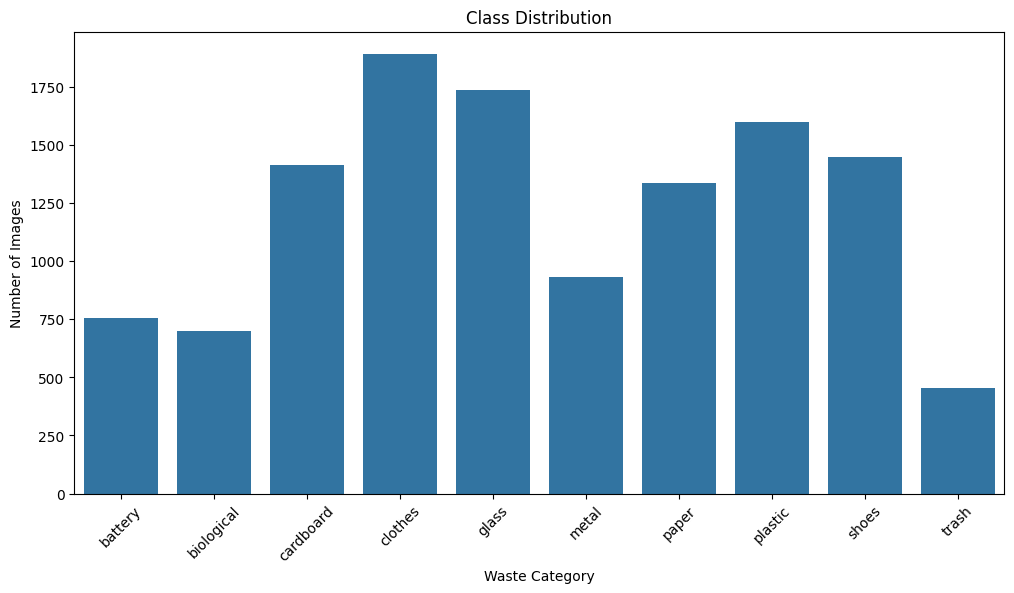

In [ ]:
counts = []

for c in sorted(classes):
    counts.append(
        len(os.listdir(os.path.join(dataset_path, c)))
    )

plt.figure(figsize=(12,6))

sns.barplot(
    x=sorted(classes),
    y=counts
)

plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")

plt.savefig("class_distribution.png")

plt.show()

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [ ]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 9811 images belonging to 10 classes.


In [ ]:
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 2448 images belonging to 10 classes.


In [ ]:
num_classes = len(classes)

cnn_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    MaxPooling2D(),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(),

    Flatten(),

    Dense(
        256,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        num_classes,
        activation='softmax'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_cnn = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1183s 4s/step - accuracy: 0.3212 - loss: 1.9595 - val_accuracy: 0.4583 - val_loss: 1.6091
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1181s 4s/step - accuracy: 0.4637 - loss: 1.5503 - val_accuracy: 0.5650 - val_loss: 1.3192
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1166s 4s/step - accuracy: 0.5177 - loss: 1.4091 - val_accuracy: 0.5658 - val_loss: 1.2692
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1153s 4s/step - accuracy: 0.5527 - loss: 1.3238 - val_accuracy: 0.6046 - val_loss: 1.1782
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1149s 4s/step - accuracy: 0.5729 - loss: 1.2615 - val_accuracy: 0.6193 - val_loss: 1.1498
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1157s 4s/step - accuracy: 0.5930 - loss: 1.1977 - val_accuracy: 0.6115 - val_loss: 1.1721
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1143s 4s/step - accuracy: 0.6117 - loss: 1.1625 - val_accuracy: 0.6352 - val_loss: 1.0954
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1141s 4s/step - accuracy: 0.6309 - loss: 1.1102 - 

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

predictions = Dense(
    num_classes,
    activation='softmax'
)(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=predictions
)

In [ ]:
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_mobile = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 582s 2s/step - accuracy: 0.7607 - loss: 0.7207 - val_accuracy: 0.8505 - val_loss: 0.4607
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 568s 2s/step - accuracy: 0.8599 - loss: 0.4200 - val_accuracy: 0.8607 - val_loss: 0.4032
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 559s 2s/step - accuracy: 0.8843 - loss: 0.3471 - val_accuracy: 0.8799 - val_loss: 0.3800
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 573s 2s/step - accuracy: 0.8916 - loss: 0.3216 - val_accuracy: 0.8783 - val_loss: 0.3784
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 564s 2s/step - accuracy: 0.8981 - loss: 0.2957 - val_accuracy: 0.8819 - val_loss: 0.3588
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 566s 2s/step - accuracy: 0.9077 - loss: 0.2811 - val_accuracy: 0.8868 - val_loss: 0.3654
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 600s 2s/step - accuracy: 0.9137 - loss: 0.2608 - val_accuracy: 0.8868 - val_loss: 0.3513
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 570s 2s/step - accuracy: 0.9176 - loss: 0.2436 - val_accu

In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [ ]:
x = GlobalAveragePooling2D()(
    base_model.output
)

output = Dense(
    num_classes,
    activation='softmax'
)(x)

resnet_model = Model(
    inputs=base_model.input,
    outputs=output
)

In [ ]:
resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history_resnet = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
  5/307 ━━━━━━━━━━━━━━━━━━━━ 25:03 5s/step - accuracy: 0.3637 - loss: 1.7983

KeyboardInterrupt: 

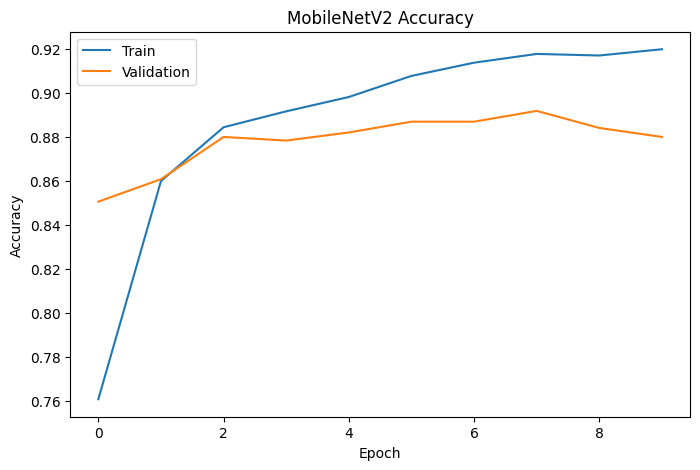

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_mobile.history['accuracy'])
plt.plot(history_mobile.history['val_accuracy'])

plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.savefig("mobilenet_accuracy.png")
plt.show()

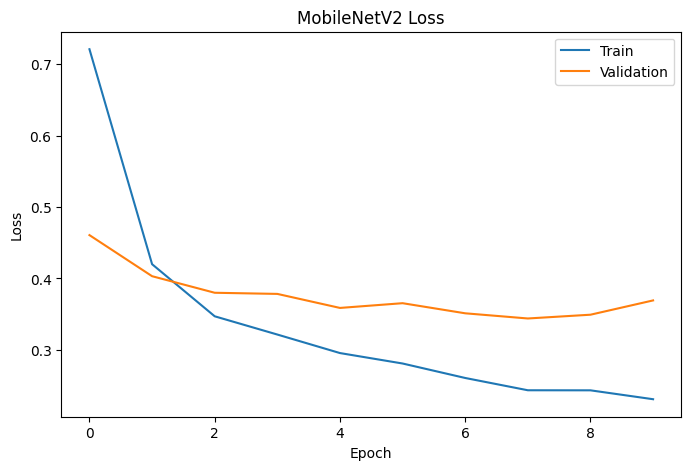

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_mobile.history['loss'])
plt.plot(history_mobile.history['val_loss'])

plt.title("MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.savefig("mobilenet_loss.png")
plt.show()

In [ ]:
predictions = mobilenet_model.predict(val_data)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = val_data.classes

77/77 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step


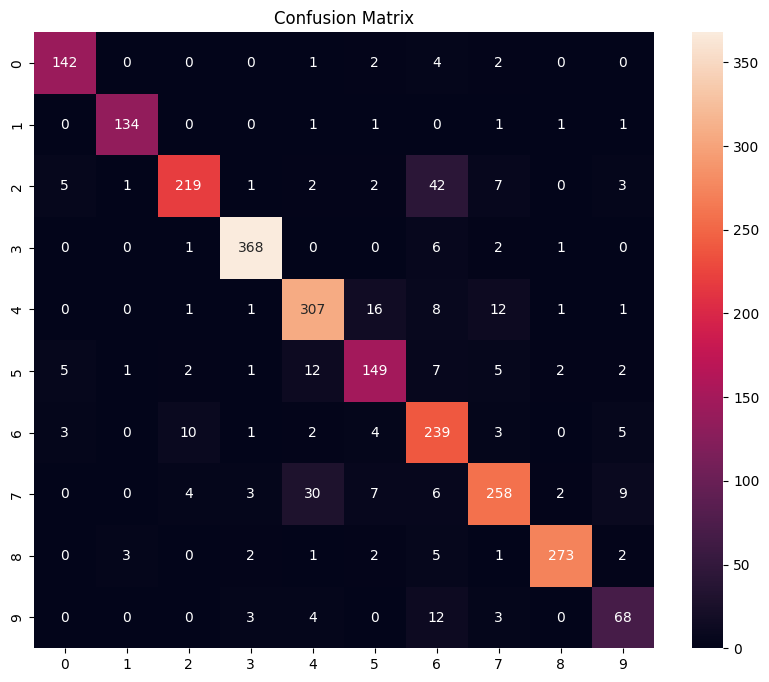

In [ ]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")
plt.show()

In [ ]:
class_names = list(val_data.class_indices.keys())

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

     battery       0.92      0.94      0.93       151
  biological       0.96      0.96      0.96       139
   cardboard       0.92      0.78      0.84       282
     clothes       0.97      0.97      0.97       378
       glass       0.85      0.88      0.87       347
       metal       0.81      0.80      0.81       186
       paper       0.73      0.90      0.80       267
     plastic       0.88      0.81      0.84       319
       shoes       0.97      0.94      0.96       289
       trash       0.75      0.76      0.75        90

    accuracy                           0.88      2448
   macro avg       0.88      0.87      0.87      2448
weighted avg       0.89      0.88      0.88      2448



In [ ]:
cnn_acc = max(history_cnn.history['val_accuracy'])
mobile_acc = max(history_mobile.history['val_accuracy'])

results = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2"],
    "Validation Accuracy": [cnn_acc, mobile_acc]
})

results

,Model,Validation Accuracy
0,Custom CNN,0.652778
1,MobileNetV2,0.891748


In [ ]:
cnn_model.save("custom_cnn.h5")
mobilenet_model.save("mobilenetv2_model.h5")